In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
import sys 
import glob
import torch 
import os
from tqdm import tqdm
from torch.utils.data import DataLoader

In [2]:
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/transforms")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/configs")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/plots")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/models")

In [26]:
from fixed_dataset import FixedDataset
from seg_recon_vit3d import SegRecon_ViT_3D
from transforms.factory import transform_factory
from utils.read_yaml import read_yaml
from utils.model_select import model_select
from utils.load_ckpt import load_best_ckpt
from loss import loss_select
from torchmetrics.image import StructuralSimilarityIndexMeasure
from metrics.sam import SAMScore
from transforms import *
from transforms import FourierSpectralTransform
from transforms.inverse_factory import *

In [29]:
def plot_channel_differences(y: torch.Tensor, out: torch.Tensor, channels: list,model_name:str, base_path = "/media/ana-caznok/SSD-08/recon-segment/"):
    """
    Plots the difference between corresponding channels of `y` and `out` for the specified channels.

    Parameters:
    - y (torch.Tensor): Tensor of shape (61, 256, 256)
    - out (torch.Tensor): Tensor of shape (1, 61, 256, 256)
    - channels (list of int): List of channel indices to plot
    """
    # Remove the batch dimension from `out`, now shape (61, 256, 256)
    out = out.squeeze(0)

    # Verify tensor shapes
    assert y.shape == out.shape == (61, 256, 256), "Shape mismatch: Expected (61, 256, 256)"

    # Compute the difference for each selected channel and store in a list
    differences = [np.abs((y[c] - out[c]).detach().cpu().numpy()) for c in channels]

    # Determine global min and max for consistent color scale
    global_min = 0 #min(diff.min() for diff in differences)
    global_max = 1 #max(diff.max() for diff in differences)

    # Determine subplot layout
    n_channels = len(channels)
    ncols = min(4, n_channels)
    nrows = (n_channels + ncols - 1) // ncols

    # Create figure and axes
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten() if n_channels > 1 else [axes]

    # Plot each channel difference
    for idx, (channel, diff) in enumerate(zip(channels, differences)):
        ax = axes[idx]
        im = ax.imshow(diff, cmap='magma', vmin=global_min, vmax=global_max)
        ax.set_title(f'Channel {channel} Difference')
        ax.axis('off')

    # Turn off unused subplots if any
    for idx in range(len(differences), len(axes)):
        axes[idx].axis('off')

    # Add a common colorbar
    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    fig.suptitle(model_name)

    # Adjust layout to prevent overlap
    #plt.tight_layout()
    plt.savefig(base_path + 'plots/' + 'err_' + model_name + '.png')

    plt.show()

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_output_channels(
    out: torch.Tensor,
    channels: list,
    model_name: str,
    base_path: str = "/media/ana-caznok/SSD-08/recon-segment/"):
    
    # Remove batch dimension, resulting shape (C, H, W)
    out = out.squeeze(0)

    # Check if output has correct dimensions
    assert out.ndim == 3, "Expected tensor shape (C, H, W) after squeezing batch dimension"

    # Extract the selected channels and move to CPU
    selected_images = [out[c].detach().cpu().numpy() for c in channels]

    # Determine layout for subplots
    n_channels = len(channels)
    ncols = min(4, n_channels)
    nrows = (n_channels + ncols - 1) // ncols

    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten() if n_channels > 1 else [axes]

    # Plot each selected channel
    for idx, (channel, img) in enumerate(zip(channels, selected_images)):
        ax = axes[idx]
        im = ax.imshow(img, cmap='gray')
        ax.set_title(f'Channel {channel}')
        ax.axis('off')

    # Turn off unused axes if there are any
    for idx in range(len(selected_images), len(axes)):
        axes[idx].axis('off')

    # Add colorbar for last image
    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    fig.suptitle(f'Output Channels - {model_name}')

    # Save the figure
    plt.savefig(base_path + 'plots/' + 'out_channels_' + model_name + '.png')
    plt.show()


In [5]:
base_path = "/media/ana-caznok/SSD-08/recon-segment/"
config_path = "/media/ana-caznok/SSD-08/recon-segment/configs/"

In [27]:
configs = ['stable_fft2ifft2hsi_1000_none_cluster_xmin.yaml',
           'fft2hsi_1000_mraessimsam_patch16.yaml', 
           'msi2hsi_1000_mraessimsam_patch16.yaml', 
           'msi2mask_wsam_1000.yaml']

In [13]:
DEVICE = 'cuda'
BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled"
PREPROCESSING = 'downsampled' 
BATCH_SIZE = 2

seg-rec_62to122_stable_stabmin
Looking for checkpoint in models/stable_fft2ifft2hsi_1000_none_cluster_xmin.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/stable_fft2ifft2hsi_1000_none_cluster_xmin.pth'


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

Loaded checkpoint from epoch: 999


/media/ana-caznok/SSD-08/recon-segment/utils/model_select.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location='cpu')


Resuming from epoch 1000/1000
Resuming W&B run ID: zti5kbrv
Selected model seg-rec_62to122_stable_stabmin: SegRecon_ViT_3D_StableTrain
Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform 
0: RGB2Pseudo_Hyp(base_path='/media/ana-caznok/SSD-08/recon-segment/', camera='cie', norm=True, return_torch=True)
1: FourierSpectralTransform(norm=None,double RealImag=True ,transform cube=False, device=cuda, shift=True,stack_type=alternate, invert=False ). Fold: None
torch.cuda.FloatTensor


/media/ana-caznok/SSD-08/recon-segment/transforms/fft_transform.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor = torch.tensor(img, dtype=torch.float32, device=device)


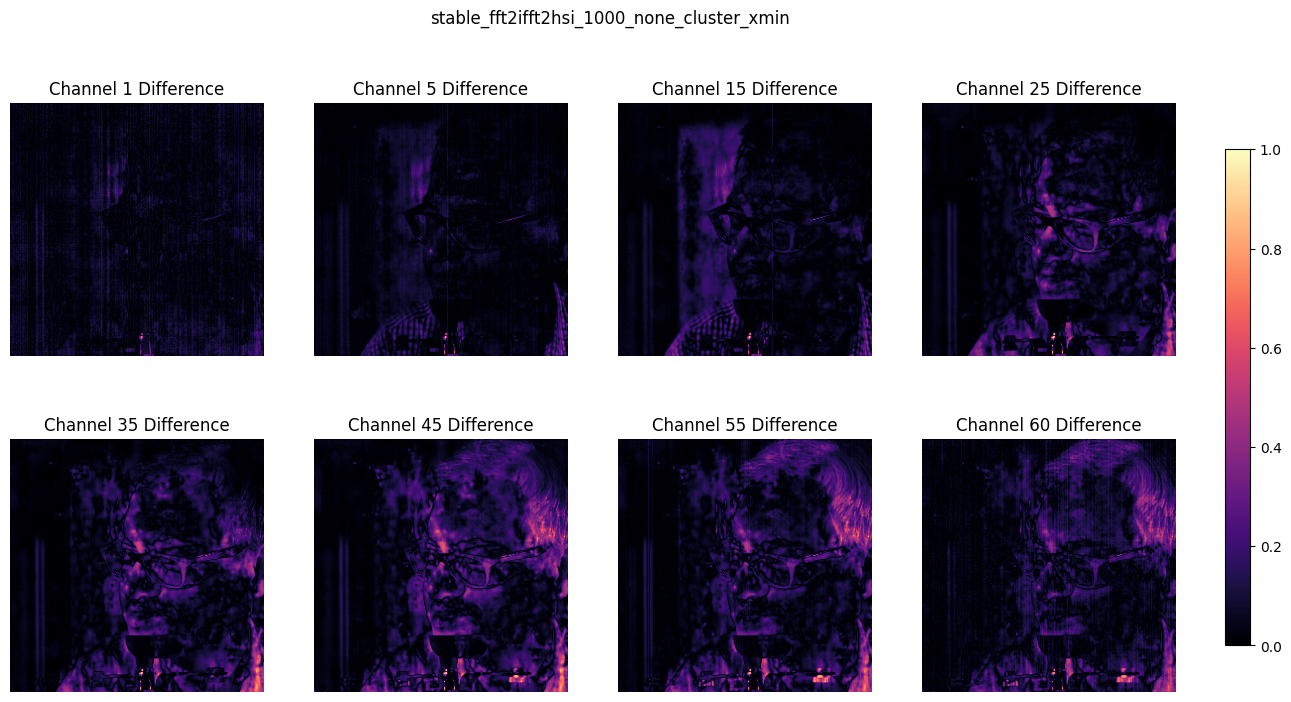

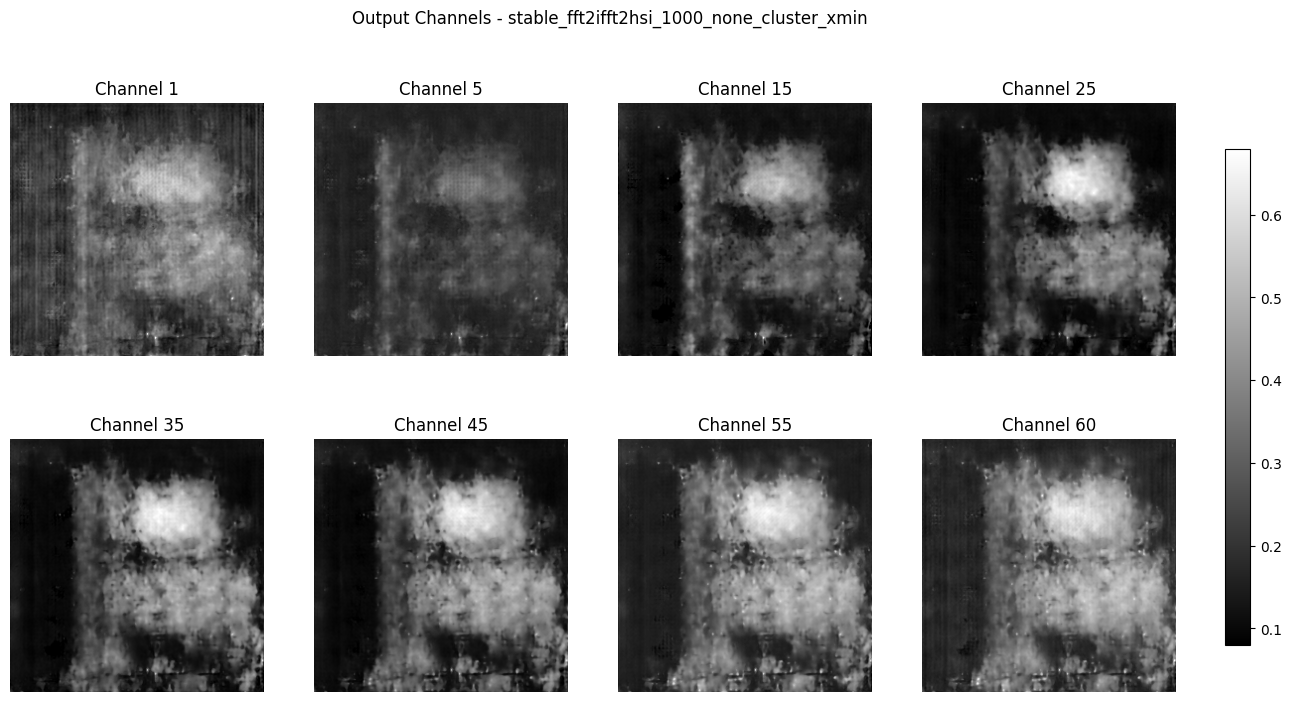

seg-rec_31to61_patch16
[512, 256, 128, 64]
RecDecoder(
  (decoder): Sequential(
    (0): ConvTranspose2d(768, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(64, 61, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): Upsample(scale_fac

/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

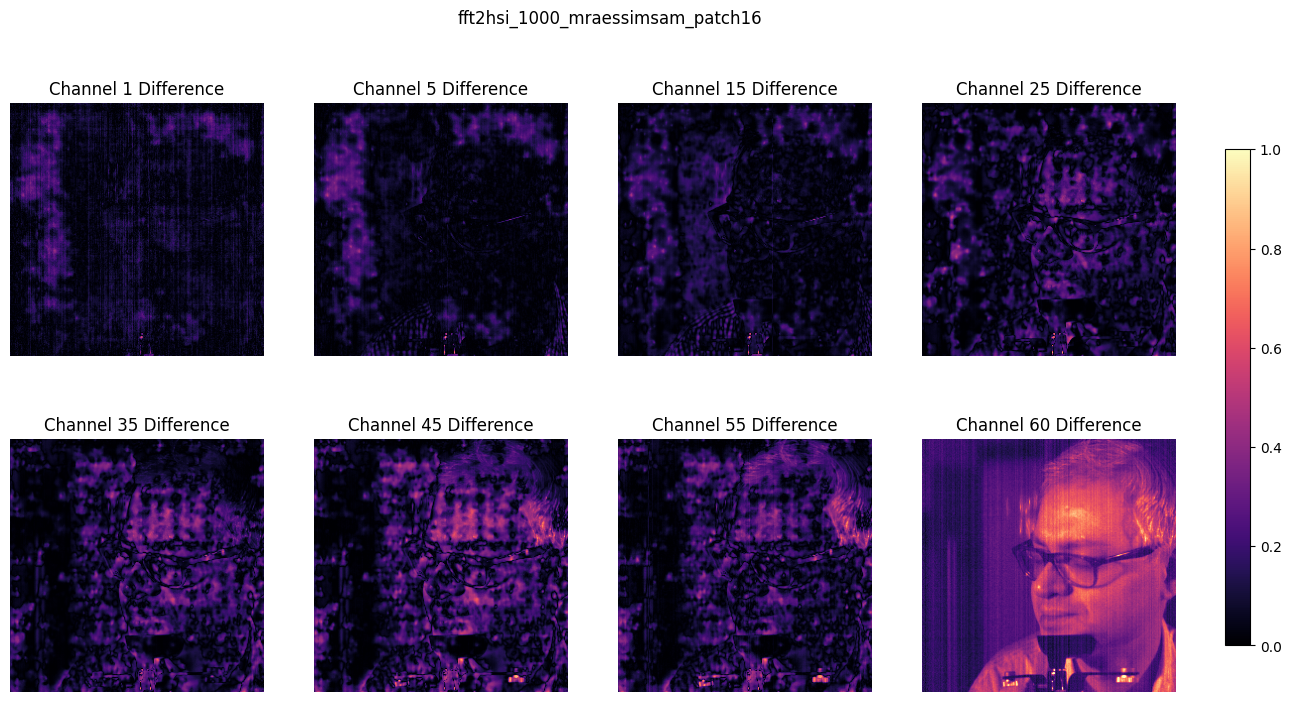

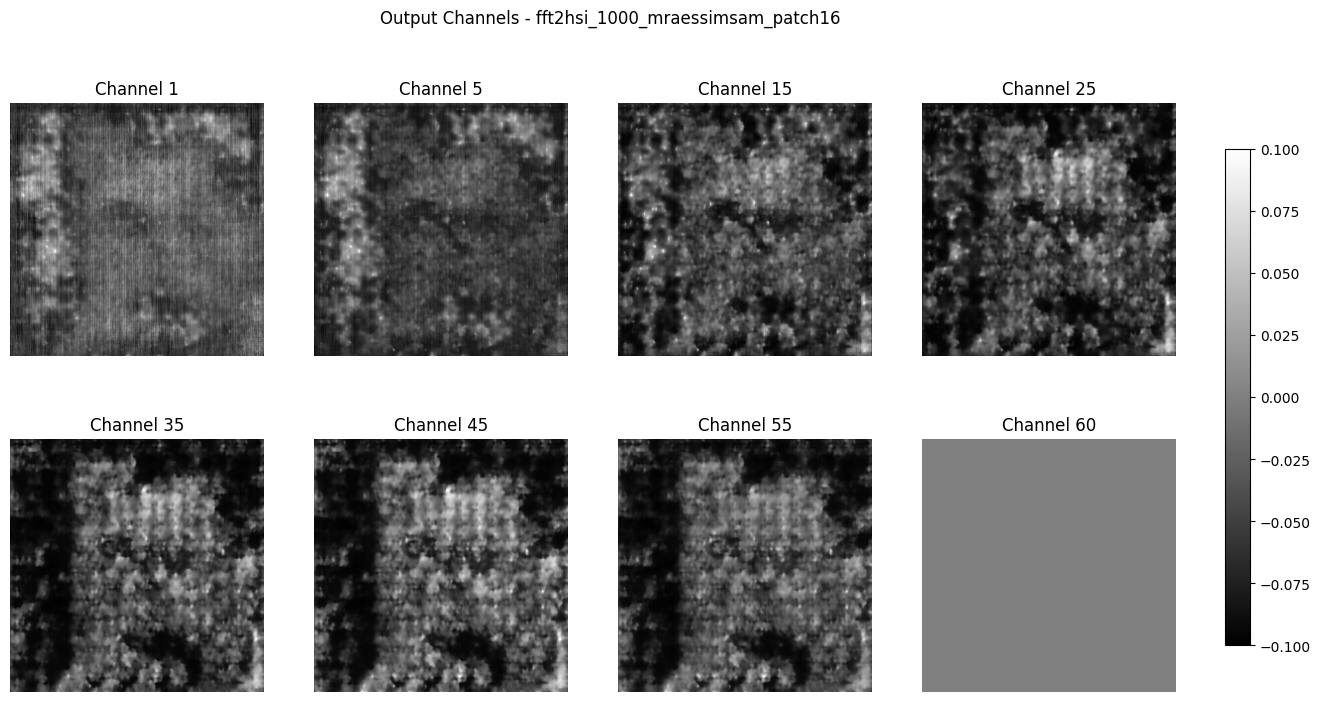

seg-rec_4to61_patch16
[512, 256, 128, 64]
RecDecoder(
  (decoder): Sequential(
    (0): ConvTranspose2d(768, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(64, 61, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): Upsample(scale_fact

/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

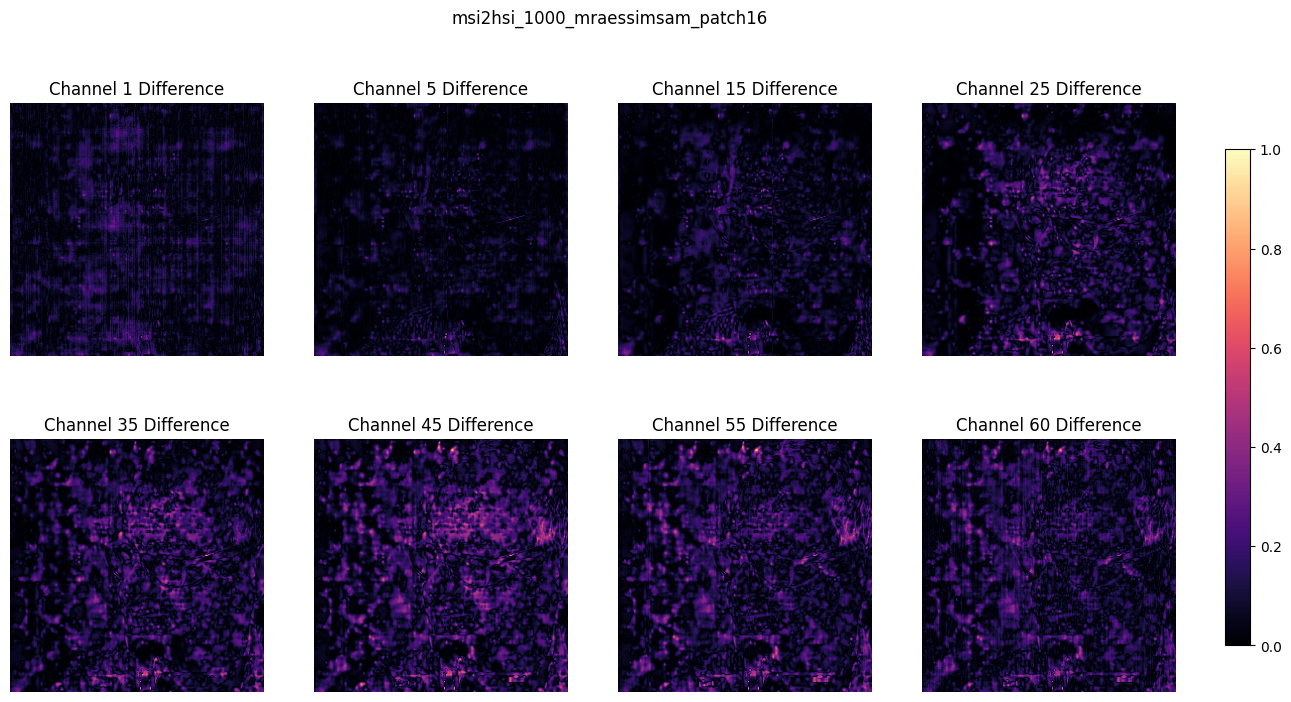

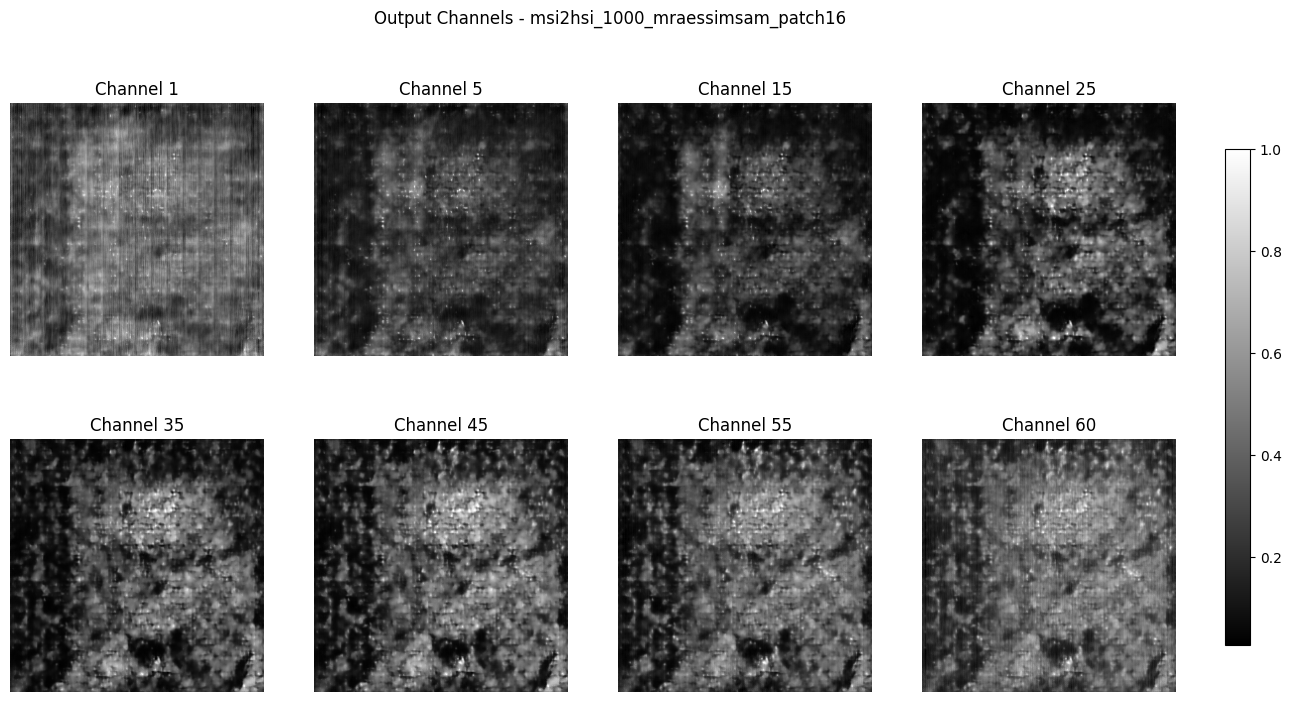

seg-rec_4to61_dual-task
[512, 256, 128, 64]
Looking for checkpoint in models/msi2mask_wsam_1000.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/msi2mask_wsam_1000.pth'
Loaded checkpoint from epoch: 999
Resuming from epoch 1000/1000
Resuming W&B run ID: t4mrk8rp
Selected model seg-rec_4to61_dual-task: SegRecon_ViT_3D_DualTask


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform None. Fold: None
torch.cuda.FloatTensor


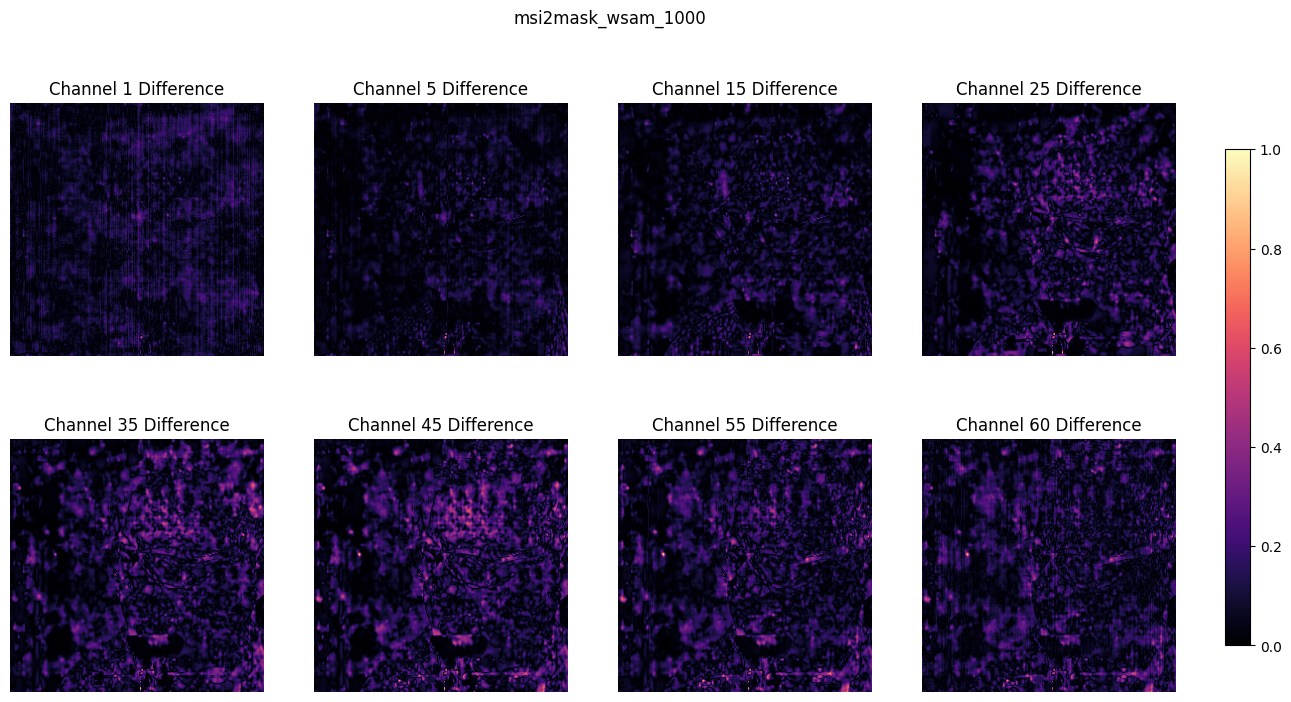

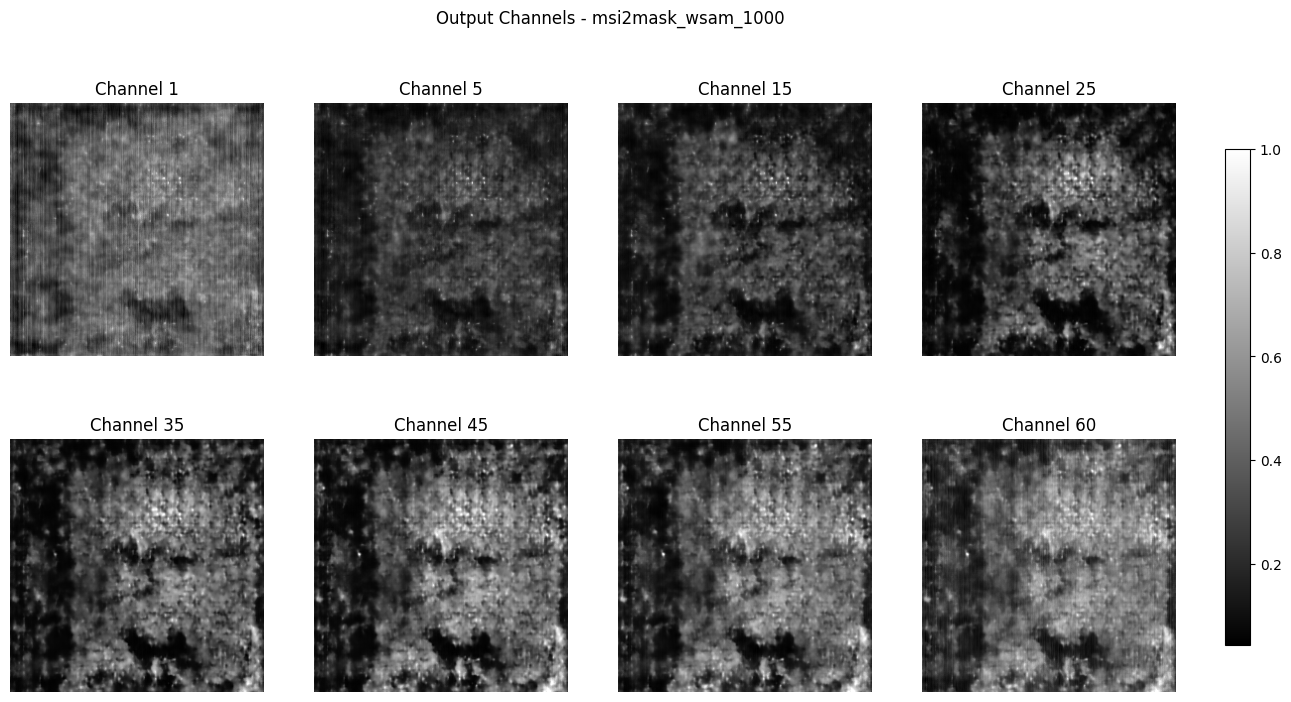

In [32]:
for config_name in configs: 
    
    config = read_yaml(config_path + config_name)

    TRANSFORM = config['valid']['transform_index']
    MODEL_NAME = config['model']
    need_ifft = bool(config['ifft'])
    print(MODEL_NAME)

    model, resume_file = model_select(config)
    model = model.to(DEVICE)

    val_dataset = FixedDataset(mode="val",
                               base_path=BASE_PATH,
                               transform=transform_factory(TRANSFORM),
                               preprocessing=PREPROCESSING)
    
    x,y,m = val_dataset[1]
    x,y = x.to(DEVICE), y.to(DEVICE)

    print(x.type())

    if 'mask' in config_name: 
        output,mask = model(x.unsqueeze(0))
    
    else: 
        output = model(x.unsqueeze(0))

        if need_ifft: 
            ifft_output_function = inverse_transform_factory(TRANSFORM,output=True)
            output = ifft_output_function(output,m)
            
    
    plot_channel_differences(y, output, channels=[1, 5, 15, 25, 35, 45, 55, 60], model_name=config_name.split('.')[0])
    plot_output_channels(output,channels=[1, 5, 15, 25, 35, 45, 55, 60],model_name= config_name.split('.')[0])

    del model 
    del resume_file
        



In [7]:
model, resume_file = model_select(config)

[512, 256, 128, 64]
Looking for checkpoint in models/msi2mask_wsam3.pth. Exact path only: True.
=> Loading model from checkpoint: 'models/msi2mask_wsam3.pth'
Loaded checkpoint from epoch: 49


/media/ana-caznok/SSD-08/recon-segment/utils/load_ckpt.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_file, map_location=torch.device('c

Resuming from epoch 50/50
Resuming W&B run ID: a6ayhur5


wandb: Currently logged in as: ana_caznok (rainbow-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Selected model seg-rec_4to61_dual-task: SegRecon_ViT_3D_DualTask


In [ ]:
# --------------------- CONFIG ---------------------
DEVICE = "cpu"
BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled"
PREPROCESSING = 'downsampled'  # or None or "downsampled"
BATCH_SIZE = 2#config['train']['batch_size']
NUM_EPOCHS = 2#config['train']['epochs']
LEARNING_RATE = config['train']['lr']
SAVE_PATH = config['fixed_checkpoint_name']
TRANSFORM = config['valid']['transform_index']
MODEL_NAME = config['model']
val_dataset = FixedDataset(
    mode="val",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),
    preprocessing=PREPROCESSING
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Number of face masks 30. initialized 30 images val DatasetRaw with preprocessing: downsampled in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2/downsampled with transform None. Fold: None


In [9]:
x,y,m = val_dataset[1]

In [10]:
output,mask = model(x.unsqueeze(0))

In [11]:
mask.shape

torch.Size([1, 1, 256, 256])

In [12]:
m['mask'].shape

torch.Size([1, 256, 256])

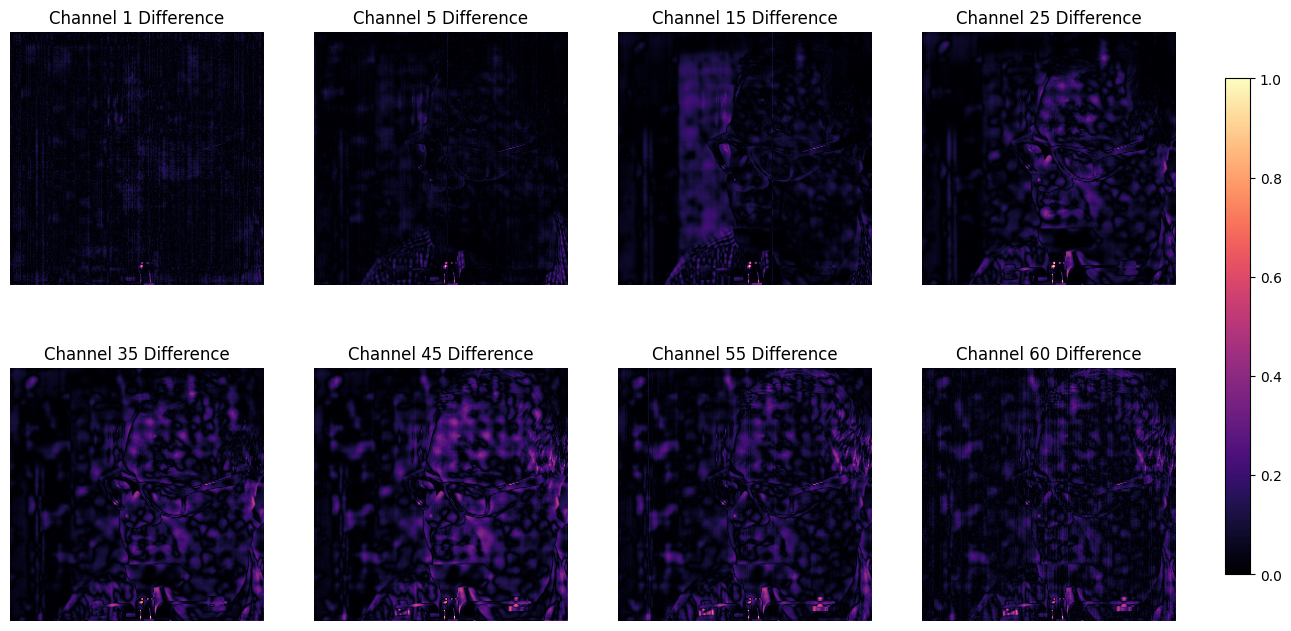

In [14]:
plot_channel_differences(y, output, channels=[1, 5, 15, 25, 35, 45, 55, 60])

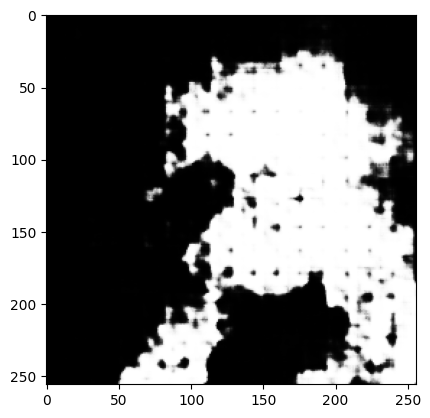

In [15]:
plot_mask = mask.detach().cpu().numpy()
plot_mask = mask[0,0,:,:].detach().numpy()
plt.imshow(plot_mask,cmap='gray')
plt.show()
#plot_mask.shape

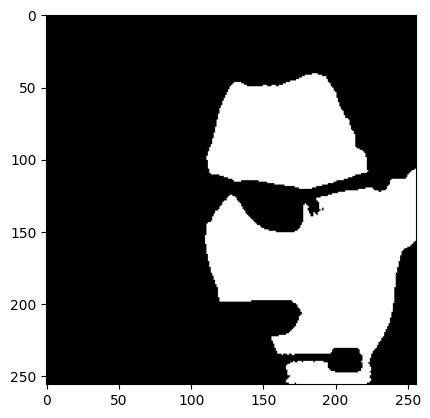

In [26]:
plot_mask = m['mask'].detach().cpu().numpy()
plot_mask = m['mask'][0,:,:].detach().numpy()
plt.imshow(plot_mask,cmap='gray')
plt.show()

In [21]:
np.unique(plot_mask.detach().numpy())

array([0.00135278, 0.00140801, 0.00161108, ..., 0.9987307 , 0.9987367 ,
       0.9988232 ], dtype=float32)

In [ ]:
pth_path= base_path + 'models/' + config_name.split('.')[0] + '.pth'

In [ ]:
model, resume_file, best_loss = load_best_ckpt(model, config, exact_only=True)
checkpoint = torch.load(resume_file, map_location='cpu')

In [ ]:
checkpoint = torch.load(pth_path, map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['state_dict'], strict=False)

#best_loss = checkpoint['best_loss']

In [ ]:
model, resume_file, best_loss = load_best_ckpt()